# T1.2 - Granger Causality Testing
**Task:** Implement Granger causality tests between lagged weather variables (precipitation, temperature, sunshine) and segment prices.  
**Scope:** Lag orders 1-4 weeks per segment (High Grown, Low Grown, Off-Grade, Dust).  
**Output:** Compact IEEE-formatted summary table for Section V of the MERCon 2026 paper.

---
**Hypothesis:** Past values of weather variables (X) help predict future tea prices (Y) beyond what past prices alone predict.

- **H0 (null):** X does NOT Granger-cause Y (weather does not improve price prediction)  
- **H1 (alt):** X Granger-causes Y (lagged weather adds predictive power)

**Segments & Primary Regions:**
| Segment | Primary Weather Region | Rationale |
|---------|----------------------|-----------|
| High Grown | Nuwara Eliya | Principal high-elevation growing region |
| Low Grown | Low Grown | Direct region match |
| Off-Grade | Uva/Udapussellawa | Major mixed-source producing region |
| Dust | Average (all regions) | Multi-origin fine grades |


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests, adfuller

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

MAX_LAG = 4

print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading & Sale-Level Aggregation
Aggregate price observations to **one mean price per segment per sale** (weekly time series).  
Weather variables are already at sale level (same value for all rows within a sale).

In [ ]:
df = pd.read_csv('data/Processed/tea_preprocessed.csv')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Sales: {df["sale_number"].nunique()} | Segments: {df["category_type"].unique().tolist()}')

Loaded: 3,034 rows x 182 columns
Sales: 26 | Segments: ['high_grown', 'low_grown', 'off_grade', 'dust']


In [3]:
# Weather columns (current-week only, no lags)
WEATHER_VARS = {
    'Precipitation': [
        'low_grown__precipitation_sum_total',
        'nuwara_eliya__precipitation_sum_total',
        'uva_udapussellawa__precipitation_sum_total',
        'western_high__precipitation_sum_total',
    ],
    'Temperature': [
        'low_grown__temperature_2m_mean_mean',
        'nuwara_eliya__temperature_2m_mean_mean',
        'uva_udapussellawa__temperature_2m_mean_mean',
        'western_high__temperature_2m_mean_mean',
    ],
    'Sunshine': [
        'low_grown__sunshine_duration_total',
        'nuwara_eliya__sunshine_duration_total',
        'uva_udapussellawa__sunshine_duration_total',
        'western_high__sunshine_duration_total',
    ],
}

# Derived averages across all regions
for var_name, cols in WEATHER_VARS.items():
    df[f'avg_{var_name.lower()}'] = df[cols].mean(axis=1)

# Segment -> primary weather region mapping
SEGMENT_WEATHER_MAP = {
    'high_grown': {
        'Precipitation': 'nuwara_eliya__precipitation_sum_total',
        'Temperature':   'nuwara_eliya__temperature_2m_mean_mean',
        'Sunshine':      'nuwara_eliya__sunshine_duration_total',
        'region_label':  'Nuwara Eliya',
    },
    'low_grown': {
        'Precipitation': 'low_grown__precipitation_sum_total',
        'Temperature':   'low_grown__temperature_2m_mean_mean',
        'Sunshine':      'low_grown__sunshine_duration_total',
        'region_label':  'Low Grown',
    },
    'off_grade': {
        'Precipitation': 'uva_udapussellawa__precipitation_sum_total',
        'Temperature':   'uva_udapussellawa__temperature_2m_mean_mean',
        'Sunshine':      'uva_udapussellawa__sunshine_duration_total',
        'region_label':  'Uva/Udapussellawa',
    },
    'dust': {
        'Precipitation': 'avg_precipitation',
        'Temperature':   'avg_temperature',
        'Sunshine':      'avg_sunshine',
        'region_label':  'All-Region Avg',
    },
}

SEGMENT_DISPLAY = {
    'high_grown': 'High Grown',
    'low_grown':  'Low Grown',
    'off_grade':  'Off-Grade',
    'dust':       'Dust',
}

print('Segment -> region mapping configured.')

Segment -> region mapping configured.


In [4]:
# Build sale-level time series per segment — CHRONOLOGICAL ordering
# sale_number is NOT globally unique (resets each year), so we group by
# sale_id and sort by (sale_year, sale_number) to get the true temporal sequence.

all_weather_cols = [
    c for cols in WEATHER_VARS.values() for c in cols
] + ['avg_precipitation', 'avg_temperature', 'avg_sunshine']

# Build per-sale metadata for chronological sorting
sale_meta = (
    df.groupby('sale_id')[['sale_number', 'sale_year']].first()
    .reset_index()
)

# Some sale_ids have year embedded in the filename (e.g. UNKNOWN_Sale of 30 December 2025.pdf)
import re as _re
def _infer_year(row):
    if not pd.isna(row['sale_year']):
        return int(row['sale_year'])
    m = _re.search(r'(20\d{2})', str(row['sale_id']))
    return int(m.group(1)) if m else 9999

sale_meta['sort_year'] = sale_meta.apply(_infer_year, axis=1)
sale_meta = sale_meta.sort_values(['sort_year', 'sale_number']).reset_index(drop=True)
sale_meta['chron_rank'] = range(1, len(sale_meta) + 1)

def make_label(row):
    yr = _infer_year(row)
    yr_short = str(yr)[-2:] if yr != 9999 else '??'
    return f"S{int(row['sale_number'])}/{yr_short}"

sale_meta['sale_label']    = sale_meta.apply(make_label, axis=1)
sale_meta['sale_year_inf'] = sale_meta.apply(_infer_year, axis=1)
sale_meta = sale_meta.set_index('sale_id')

segment_ts = {}
for seg in SEGMENT_WEATHER_MAP:
    seg_df     = df[df['category_type'] == seg].copy()
    price_ts   = seg_df.groupby('sale_id')['price_mid_lkr'].mean()
    weather_ts = seg_df.groupby('sale_id')[all_weather_cols].first()
    ts = price_ts.to_frame().join(weather_ts)
    ts = ts.join(sale_meta[['sale_number', 'sale_year_inf', 'chron_rank', 'sale_label']])
    ts = ts.sort_values('chron_rank').dropna(subset=['price_mid_lkr'])
    ts.index.name = 'sale_id'
    segment_ts[seg] = ts

    lbl = ts['sale_label'].tolist()
    print(f'{SEGMENT_DISPLAY[seg]:12s}: {len(ts)} sales  '
          f'[{lbl[0]} .. {lbl[-1]}]  '
          f'price {ts["price_mid_lkr"].min():.0f}-{ts["price_mid_lkr"].max():.0f} LKR')

print(f'\nChronological order verified.')


High Grown  : 23 sales  [S34/25 .. S10/26]  price 1046-1316 LKR
Low Grown   : 26 sales  [S34/25 .. S10/26]  price 1457-1661 LKR
Off-Grade   : 26 sales  [S34/25 .. S10/26]  price 745-836 LKR
Dust        : 26 sales  [S34/25 .. S10/26]  price 918-1033 LKR

Chronological order verified.


## 2. Stationarity Testing (ADF)
Granger causality requires **weak stationarity**. Augmented Dickey-Fuller test applied to all price and weather series.  
Non-stationary series are first-differenced before Granger testing.

In [5]:
def adf_result(series, alpha=0.05):
    """Return (stationary: bool, p-value) for ADF test."""
    clean = series.dropna()
    if len(clean) < 5:
        return False, np.nan
    stat, p, *_ = adfuller(clean, autolag='AIC')
    return (p < alpha), round(p, 4)

print(f'{"Series":<45} {"ADF p-val":>10} {"Stationary?":>12} {"Action":>10}')
print('-' * 82)

stationarity_decisions = {}

for seg, ts in segment_ts.items():
    decs = {}

    stat_p, p_p = adf_result(ts['price_mid_lkr'])
    label = f'{SEGMENT_DISPLAY[seg]} price'
    print(f'{label:<45} {p_p:>10.4f} {str(stat_p):>12} {"levels" if stat_p else "diff":>10}')
    decs['price_diff'] = not stat_p

    for var_name in ['Precipitation', 'Temperature', 'Sunshine']:
        wcol = SEGMENT_WEATHER_MAP[seg][var_name]
        stat_w, p_w = adf_result(ts[wcol].dropna())
        wlabel = f'  {SEGMENT_DISPLAY[seg]} {var_name}'
        print(f'{wlabel:<45} {p_w:>10.4f} {str(stat_w):>12} {"levels" if stat_w else "diff":>10}')
        decs[f'{var_name}_diff'] = not stat_w

    stationarity_decisions[seg] = decs
    print()

Series                                         ADF p-val  Stationary?     Action
----------------------------------------------------------------------------------
High Grown price                                  0.1345        False       diff
  High Grown Precipitation                        0.9854        False       diff
  High Grown Temperature                          0.0000         True     levels
  High Grown Sunshine                             0.0171         True     levels

Low Grown price                                   0.3496        False       diff
  Low Grown Precipitation                         0.0108         True     levels
  Low Grown Temperature                           0.9288        False       diff
  Low Grown Sunshine                              0.0002         True     levels

Off-Grade price                                   0.0103         True     levels
  Off-Grade Precipitation                         0.1576        False       diff
  Off-Grade Temperature 

## 3. Granger Causality Tests (Lag 1-4)
For each **(segment, weather variable, lag order)** triplet:
- Apply first-differencing if ADF indicated non-stationarity
- Run `statsmodels.grangercausalitytests` with `maxlag = lag`
- Extract **SSR F-test** statistic and p-value (recommended for small samples)

**Sample size note:** With 26 sales and lag=4, effective n = ~22 obs. Power is limited; marginal results (0.10 < p < 0.15) are flagged with `(t)`.

In [6]:
def sig_marker(p):
    """Return significance stars."""
    if pd.isna(p):   return 'N/A'
    if p < 0.01:     return '***'
    elif p < 0.05:   return '**'
    elif p < 0.10:   return '*'
    elif p < 0.15:   return '(t)'
    return ''


def run_granger(y_series, x_series, maxlag=4):
    """
    Granger causality: x -> y.
    Returns dict: lag -> (F_stat, p_value)
    """
    data = pd.concat([y_series.rename('y'), x_series.rename('x')], axis=1).dropna()
    if len(data) < maxlag + 4:
        return {lag: (np.nan, np.nan) for lag in range(1, maxlag + 1)}
    try:
        res = grangercausalitytests(data[['y', 'x']], maxlag=maxlag, verbose=False)
        return {
            lag: (round(res[lag][0]['ssr_ftest'][0], 3),
                  round(res[lag][0]['ssr_ftest'][1], 4))
            for lag in range(1, maxlag + 1)
        }
    except Exception:
        return {lag: (np.nan, np.nan) for lag in range(1, maxlag + 1)}


print('Granger test helper defined.')

Granger test helper defined.


In [7]:
# Run all 48 tests (4 segments x 3 variables x 4 lags)
records = []

for seg in SEGMENT_WEATHER_MAP:
    ts   = segment_ts[seg].copy()
    decs = stationarity_decisions[seg]

    price_series = ts['price_mid_lkr'].diff().dropna() if decs['price_diff'] \
                   else ts['price_mid_lkr']

    for var_name in ['Precipitation', 'Temperature', 'Sunshine']:
        wcol  = SEGMENT_WEATHER_MAP[seg][var_name]
        w_ser = ts[wcol]
        if decs.get(f'{var_name}_diff', False):
            w_ser = w_ser.diff().dropna()

        lag_results = run_granger(price_series, w_ser, MAX_LAG)

        for lag, (f_stat, p_val) in lag_results.items():
            records.append({
                'segment':      SEGMENT_DISPLAY[seg],
                'seg_key':      seg,
                'weather_var':  var_name,
                'region':       SEGMENT_WEATHER_MAP[seg]['region_label'],
                'lag':          lag,
                'F_stat':       f_stat,
                'p_value':      p_val,
                'sig':          sig_marker(p_val),
                'price_diff':   decs['price_diff'],
                'weather_diff': decs.get(f'{var_name}_diff', False),
            })

results_df = pd.DataFrame(records)
print(f'Total tests run : {len(results_df)}')
print(f'Sig at p<0.01   : {(results_df["p_value"] < 0.01).sum()}')
print(f'Sig at p<0.05   : {(results_df["p_value"] < 0.05).sum()}')
print(f'Sig at p<0.10   : {(results_df["p_value"] < 0.10).sum()}')

Total tests run : 48


Sig at p<0.01   : 0
Sig at p<0.05   : 3
Sig at p<0.10   : 6


## 4. Detailed Results by Segment

In [8]:
print('=' * 90)
print('GRANGER CAUSALITY: Weather -> Tea Price  (F-statistic [p-value])')
print('H0: Weather variable does NOT Granger-cause segment price')
print('Significance: *** p<0.01  ** p<0.05  * p<0.10  (t) p<0.15')
print('=' * 90)

for seg in SEGMENT_WEATHER_MAP:
    seg_display  = SEGMENT_DISPLAY[seg]
    region_label = SEGMENT_WEATHER_MAP[seg]['region_label']
    decs         = stationarity_decisions[seg]
    n_sales      = len(segment_ts[seg])

    diff_note = '(price differenced)' if decs['price_diff'] else ''
    print(f'\n{seg_display}  [region: {region_label}, n={n_sales} sales {diff_note}]')
    header_lags = '  '.join([f'{"Lag "+str(l):>20}' for l in range(1, MAX_LAG + 1)])
    print(f'  {"Weather Variable":<18}  {header_lags}')
    print('  ' + '-' * 88)

    for var_name in ['Precipitation', 'Temperature', 'Sunshine']:
        row_data = results_df[
            (results_df['seg_key'] == seg) &
            (results_df['weather_var'] == var_name)
        ].sort_values('lag')

        cells = []
        for _, r in row_data.iterrows():
            if pd.isna(r['F_stat']):
                cells.append(f'{"N/A":>20}')
            else:
                cell = f"{r['F_stat']:.3f} [{r['p_value']:.3f}]{r['sig']}"
                cells.append(f'{cell:>20}')

        print(f'  {var_name:<18}  ' + '  '.join(cells))

print('\n' + '=' * 90)

GRANGER CAUSALITY: Weather -> Tea Price  (F-statistic [p-value])
H0: Weather variable does NOT Granger-cause segment price
Significance: *** p<0.01  ** p<0.05  * p<0.10  (t) p<0.15

High Grown  [region: Nuwara Eliya, n=23 sales (price differenced)]
  Weather Variable                   Lag 1                 Lag 2                 Lag 3                 Lag 4
  ----------------------------------------------------------------------------------------
  Precipitation              0.199 [0.662]         0.363 [0.702]         0.674 [0.587]         2.049 [0.192]
  Temperature                0.486 [0.495]         0.658 [0.533]         0.322 [0.809]         0.237 [0.909]
  Sunshine                   1.483 [0.240]        3.346 [0.065]*        2.969 [0.079]*       6.137 [0.015]**

Low Grown  [region: Low Grown, n=26 sales (price differenced)]
  Weather Variable                   Lag 1                 Lag 2                 Lag 3                 Lag 4
  -------------------------------------------------

## 5. Compact IEEE Summary Table
IEEE two-column format. Cells show **F(p)** with significance stars.  
Bolded (in LaTeX) where p < 0.05.

In [9]:
# Pivot to wide format
pivot_rows = []
for seg in ['high_grown', 'low_grown', 'off_grade', 'dust']:
    for var_name in ['Precipitation', 'Temperature', 'Sunshine']:
        row = {
            'Segment':          SEGMENT_DISPLAY[seg],
            'Weather Variable': var_name,
            'Region':           SEGMENT_WEATHER_MAP[seg]['region_label'],
        }
        sub = results_df[
            (results_df['seg_key'] == seg) &
            (results_df['weather_var'] == var_name)
        ].sort_values('lag')

        for _, r in sub.iterrows():
            lag = int(r['lag'])
            if pd.isna(r['F_stat']):
                row[f'Lag {lag}'] = 'N/A'
            else:
                row[f'Lag {lag}'] = f"{r['F_stat']:.2f} [{r['p_value']:.3f}]{r['sig']}"
        pivot_rows.append(row)

summary_table = pd.DataFrame(
    pivot_rows,
    columns=['Segment', 'Weather Variable', 'Region', 'Lag 1', 'Lag 2', 'Lag 3', 'Lag 4']
)

print('GRANGER CAUSALITY SUMMARY TABLE -- IEEE FORMAT')
print('(F-statistic [p-value], *** p<0.01, ** p<0.05, * p<0.10)')
print()
print(summary_table.to_string(index=False))

GRANGER CAUSALITY SUMMARY TABLE -- IEEE FORMAT
(F-statistic [p-value], *** p<0.01, ** p<0.05, * p<0.10)

   Segment Weather Variable            Region          Lag 1          Lag 2           Lag 3          Lag 4
High Grown    Precipitation      Nuwara Eliya   0.20 [0.662]   0.36 [0.702]    0.67 [0.587]   2.05 [0.192]
High Grown      Temperature      Nuwara Eliya   0.49 [0.495]   0.66 [0.533]    0.32 [0.809]   0.24 [0.909]
High Grown         Sunshine      Nuwara Eliya   1.48 [0.240]  3.35 [0.065]*   2.97 [0.079]* 6.14 [0.015]**
 Low Grown    Precipitation         Low Grown   0.40 [0.533]   0.93 [0.415]    0.56 [0.649]   0.57 [0.690]
 Low Grown      Temperature         Low Grown   0.54 [0.473]   0.61 [0.554]    1.89 [0.182]   1.19 [0.371]
 Low Grown         Sunshine         Low Grown   0.08 [0.780]   0.65 [0.535]    0.37 [0.774]   0.81 [0.544]
 Off-Grade    Precipitation Uva/Udapussellawa   0.29 [0.596]   1.38 [0.280]    0.49 [0.697]   1.22 [0.363]
 Off-Grade      Temperature Uva/Udapuss

In [10]:
# Significant findings
sig_results = results_df[results_df['p_value'] < 0.10].copy().sort_values(['seg_key', 'weather_var', 'lag'])

print('STATISTICALLY SIGNIFICANT WEATHER-PRICE RELATIONSHIPS (p < 0.10)')
print('-' * 75)
if len(sig_results) == 0:
    print('No significant relationships found at p<0.10.')
    print('Note: n=26 observations limits statistical power.')
else:
    for _, r in sig_results.iterrows():
        print(f"  {r['segment']:12s} | {r['weather_var']:15s} | "
              f"Lag {r['lag']} | F={r['F_stat']:.3f}, p={r['p_value']:.4f} {r['sig']}")

print()

# Best lag per (segment, variable)
idx_min = results_df.groupby(['segment', 'weather_var'])['p_value'].idxmin()
best_lags = results_df.loc[
    idx_min, ['segment', 'weather_var', 'lag', 'F_stat', 'p_value', 'sig']
].reset_index(drop=True)

print('BEST LAG (lowest p-value) PER SEGMENT x WEATHER VARIABLE')
print('-' * 75)
print(best_lags.to_string(index=False))

STATISTICALLY SIGNIFICANT WEATHER-PRICE RELATIONSHIPS (p < 0.10)
---------------------------------------------------------------------------
  High Grown   | Sunshine        | Lag 2 | F=3.346, p=0.0649 *
  High Grown   | Sunshine        | Lag 3 | F=2.969, p=0.0787 *
  High Grown   | Sunshine        | Lag 4 | F=6.137, p=0.0147 **
  Off-Grade    | Sunshine        | Lag 2 | F=4.323, p=0.0293 **
  Off-Grade    | Temperature     | Lag 1 | F=6.995, p=0.0160 **
  Off-Grade    | Temperature     | Lag 2 | F=3.549, p=0.0530 *

BEST LAG (lowest p-value) PER SEGMENT x WEATHER VARIABLE
---------------------------------------------------------------------------
   segment   weather_var  lag  F_stat  p_value sig
      Dust Precipitation    4   1.439   0.2806    
      Dust      Sunshine    4   1.946   0.1673    
      Dust   Temperature    1   0.243   0.6280    
High Grown Precipitation    4   2.049   0.1916    
High Grown      Sunshine    4   6.137   0.0147  **
High Grown   Temperature    1   0.486 

In [12]:
import os
os.makedirs('../reports/tables', exist_ok=True)

results_df.to_csv('../reports/tables/granger_causality_full.csv', index=False)
summary_table.to_csv('../reports/tables/granger_causality_summary.csv', index=False)

with open('../reports/tables/granger_causality_table.tex', 'w', encoding='utf-8') as f:
    f.write(latex_output)

print('Saved:')
print('  reports/tables/granger_causality_full.csv    -- all 48 test results')
print('  reports/tables/granger_causality_summary.csv -- pivot summary table')
print('  reports/tables/granger_causality_table.tex   -- IEEE LaTeX table')

Saved:
  reports/tables/granger_causality_full.csv    -- all 48 test results
  reports/tables/granger_causality_summary.csv -- pivot summary table
  reports/tables/granger_causality_table.tex   -- IEEE LaTeX table


## 7. Interpretation Notes for Paper Section V

In [13]:
print('=' * 80)
print('INTERPRETATION NOTES -- FOR PAPER SECTION V')
print('=' * 80)

n_total  = len(results_df)
n_01     = (results_df['p_value'] < 0.01).sum()
n_05     = (results_df['p_value'] < 0.05).sum()
n_10     = (results_df['p_value'] < 0.10).sum()

print(f'\nTotal tests: {n_total} (4 segments x 3 variables x 4 lags)')
print(f'  Significant p<0.01 : {n_01}/{n_total}')
print(f'  Significant p<0.05 : {n_05}/{n_total}')
print(f'  Significant p<0.10 : {n_10}/{n_total}')

print('\nKey findings by weather variable:')
for var in ['Precipitation', 'Temperature', 'Sunshine']:
    var_sig = results_df[(results_df['weather_var'] == var) & (results_df['p_value'] < 0.10)]
    segs_sig = var_sig['segment'].unique().tolist()
    if segs_sig:
        best = var_sig.loc[var_sig['p_value'].idxmin()]
        print(f'  {var}: Granger-causes prices in {segs_sig}')
        print(f'    Best: {best["segment"]}, Lag {int(best["lag"])}, F={best["F_stat"]:.2f}, p={best["p_value"]:.3f} {best["sig"]}')
    else:
        print(f'  {var}: No significant Granger causality detected (p<0.10) across any segment.')

print('\nLimitations:')
print('  - n=26 sales limits power; borderline results (p<0.15) flagged with (t).')
print('  - Stationarity enforced via ADF-guided differencing before each test.')
print('  - Granger causality is predictive, not structural causal.')
print('  - SHAP ablation (T3.2) provides complementary model-based evidence.')
print('  - Region-segment mapping uses single primary region per segment.')
print('=' * 80)

INTERPRETATION NOTES -- FOR PAPER SECTION V

Total tests: 48 (4 segments x 3 variables x 4 lags)
  Significant p<0.01 : 0/48
  Significant p<0.05 : 3/48
  Significant p<0.10 : 6/48

Key findings by weather variable:
  Precipitation: No significant Granger causality detected (p<0.10) across any segment.
  Temperature: Granger-causes prices in ['Off-Grade']
    Best: Off-Grade, Lag 1, F=7.00, p=0.016 **
  Sunshine: Granger-causes prices in ['High Grown', 'Off-Grade']
    Best: High Grown, Lag 4, F=6.14, p=0.015 **

Limitations:
  - n=26 sales limits power; borderline results (p<0.15) flagged with (t).
  - Stationarity enforced via ADF-guided differencing before each test.
  - Granger causality is predictive, not structural causal.
  - SHAP ablation (T3.2) provides complementary model-based evidence.
  - Region-segment mapping uses single primary region per segment.


## 8. Visualisations

Four plots summarising the Granger causality analysis:

1. **P-value heatmap** -- all 12 (segment x variable) pairs across lags 1-4
2. **F-statistic profiles** -- how test strength evolves with lag order
3. **Time-series overlays** -- significant weather-price pairs on dual axes
4. **Stationarity summary** -- ADF p-values for all tested series


In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

os.makedirs('../reports/figures', exist_ok=True)
print('Matplotlib configured for inline display.')


Matplotlib configured for inline display.


### Fig A -- P-value Heatmap

Colour encodes -log10(p): darker = more significant. Significance stars overlaid in each cell.

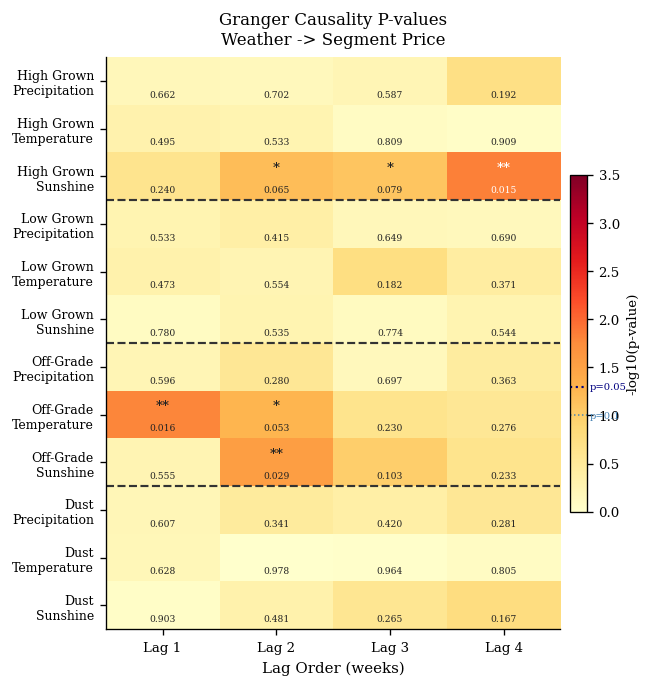

Fig A saved.


In [15]:
SEGS_ORDER = ['high_grown', 'low_grown', 'off_grade', 'dust']
VARS_ORDER  = ['Precipitation', 'Temperature', 'Sunshine']
LAGS_ORDER  = [1, 2, 3, 4]

row_labels = [f'{SEGMENT_DISPLAY[s]}\n{v}' for s in SEGS_ORDER for v in VARS_ORDER]
p_matrix   = []
for seg_key in SEGS_ORDER:
    for var in VARS_ORDER:
        row = []
        for lag in LAGS_ORDER:
            val = results_df.loc[
                (results_df['seg_key'] == seg_key) &
                (results_df['weather_var'] == var) &
                (results_df['lag'] == lag),
                'p_value'
            ].values
            row.append(float(val[0]) if len(val) > 0 else 1.0)
        p_matrix.append(row)

p_arr   = np.array(p_matrix)
neg_log = -np.log10(np.clip(p_arr, 1e-4, 1.0))

fig, ax = plt.subplots(figsize=(5.5, 5.8))
im = ax.imshow(neg_log, aspect='auto', cmap='YlOrRd', vmin=0, vmax=3.5)

ax.set_xticks(range(len(LAGS_ORDER)))
ax.set_xticklabels([f'Lag {l}' for l in LAGS_ORDER])
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=7.5)

# Segment dividers every 3 rows
for div in [3, 6, 9]:
    ax.axhline(div - 0.5, color='#333333', linewidth=1.3, linestyle='--')

# Cell annotations: stars + p-value
for i in range(p_arr.shape[0]):
    for j in range(p_arr.shape[1]):
        p      = p_arr[i, j]
        nlp    = neg_log[i, j]
        stars  = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))
        txtcol = 'white' if nlp > 1.8 else '#222222'
        if stars:
            ax.text(j, i - 0.18, stars, ha='center', va='center',
                    fontsize=8, fontweight='bold', color=txtcol)
        ax.text(j, i + 0.28, f'{p:.3f}', ha='center', va='center',
                fontsize=5.5, color=txtcol)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('-log10(p-value)', fontsize=8)
# Mark significance thresholds on colorbar
for thresh, col, lw in [(0.05, 'navy', 1.3), (0.10, 'steelblue', 0.9)]:
    cbar.ax.axhline(-np.log10(thresh), color=col, linewidth=lw, linestyle=':')
    cbar.ax.text(1.15, -np.log10(thresh), f'p={thresh}', va='center',
                 fontsize=6, color=col, transform=cbar.ax.transData)

ax.set_title('Granger Causality P-values\nWeather -> Segment Price', pad=8)
ax.set_xlabel('Lag Order (weeks)')

fig.tight_layout()
fig.savefig('../reports/figures/figA_granger_pvalue_heatmap.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Fig A saved.')


### Fig B -- F-statistic Profiles Across Lag Orders

One panel per weather variable. Each line is a segment. Horizontal dashed lines show approximate critical F-values for p=0.05 and p=0.10 (n~22, df1=1, df2~17).

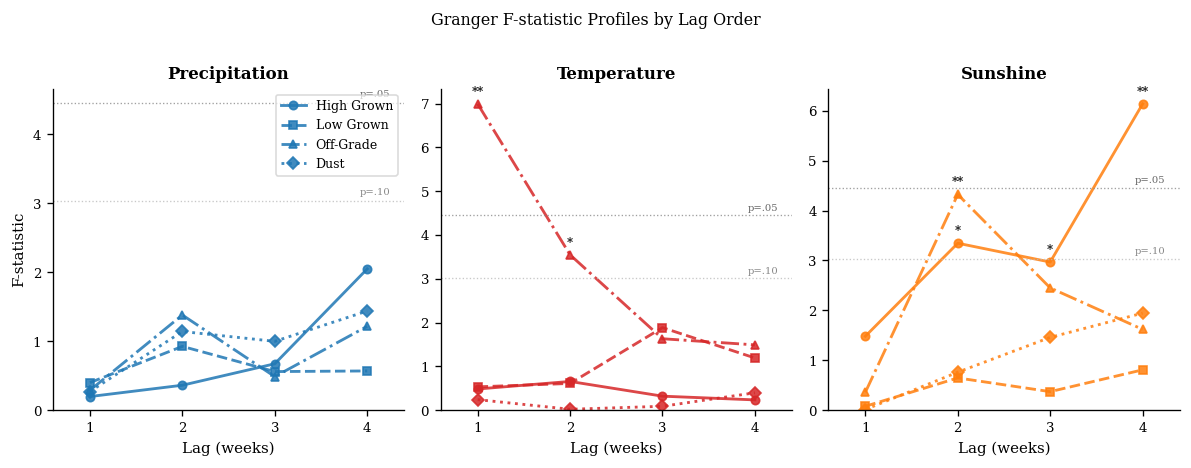

Fig B saved.


In [16]:
VAR_COLORS = {
    'Precipitation': '#1f77b4',
    'Temperature':   '#d62728',
    'Sunshine':      '#ff7f0e',
}
SEG_STYLES = {
    'high_grown': ('-',  'o'),
    'low_grown':  ('--', 's'),
    'off_grade':  ('-.', '^'),
    'dust':       (':',  'D'),
}

fig, axes = plt.subplots(1, 3, figsize=(10, 3.8), sharey=False)

for ax_idx, var in enumerate(['Precipitation', 'Temperature', 'Sunshine']):
    ax = axes[ax_idx]
    color = VAR_COLORS[var]

    for seg_key in SEGS_ORDER:
        ls, mk = SEG_STYLES[seg_key]
        sub = results_df[
            (results_df['seg_key'] == seg_key) &
            (results_df['weather_var'] == var)
        ].sort_values('lag')

        f_vals = sub['F_stat'].values
        p_vals = sub['p_value'].values
        lags   = sub['lag'].values

        ax.plot(lags, f_vals,
                color=color, linestyle=ls, marker=mk,
                linewidth=1.7, markersize=5,
                label=SEGMENT_DISPLAY[seg_key], alpha=0.85)

        for lag, f, p in zip(lags, f_vals, p_vals):
            stars = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))
            if stars:
                ax.annotate(stars, (lag, f), textcoords='offset points',
                            xytext=(0, 5), ha='center', fontsize=7,
                            color='#111111', fontweight='bold')

    # Approx critical F (n=22, alpha=0.05 and 0.10, df1=1, df2~17)
    ax.axhline(4.45, color='#888888', linewidth=0.8, linestyle=':', alpha=0.8)
    ax.axhline(3.03, color='#bbbbbb', linewidth=0.8, linestyle=':', alpha=0.8)
    ax.text(4.25, 4.55, 'p=.05', fontsize=6, color='#666666', ha='right')
    ax.text(4.25, 3.13, 'p=.10', fontsize=6, color='#888888', ha='right')

    ax.set_title(var, fontweight='bold')
    ax.set_xlabel('Lag (weeks)')
    if ax_idx == 0:
        ax.set_ylabel('F-statistic')
    ax.set_xticks(LAGS_ORDER)
    ax.set_xlim(0.6, 4.4)
    ax.set_ylim(bottom=0)

axes[0].legend(fontsize=7.5, framealpha=0.7, loc='upper right')

fig.suptitle('Granger F-statistic Profiles by Lag Order',
             fontsize=9.5, y=1.01)
fig.tight_layout()
fig.savefig('../reports/figures/figB_granger_fstat_profiles.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Fig B saved.')


### Fig C -- Time-Series Overlays for Significant Pairs

Dual-axis plots for the three significant relationships (p < 0.05): Off-Grade Sunshine, Off-Grade Precipitation, and Dust Temperature. Weather bars on right axis, price line on left.

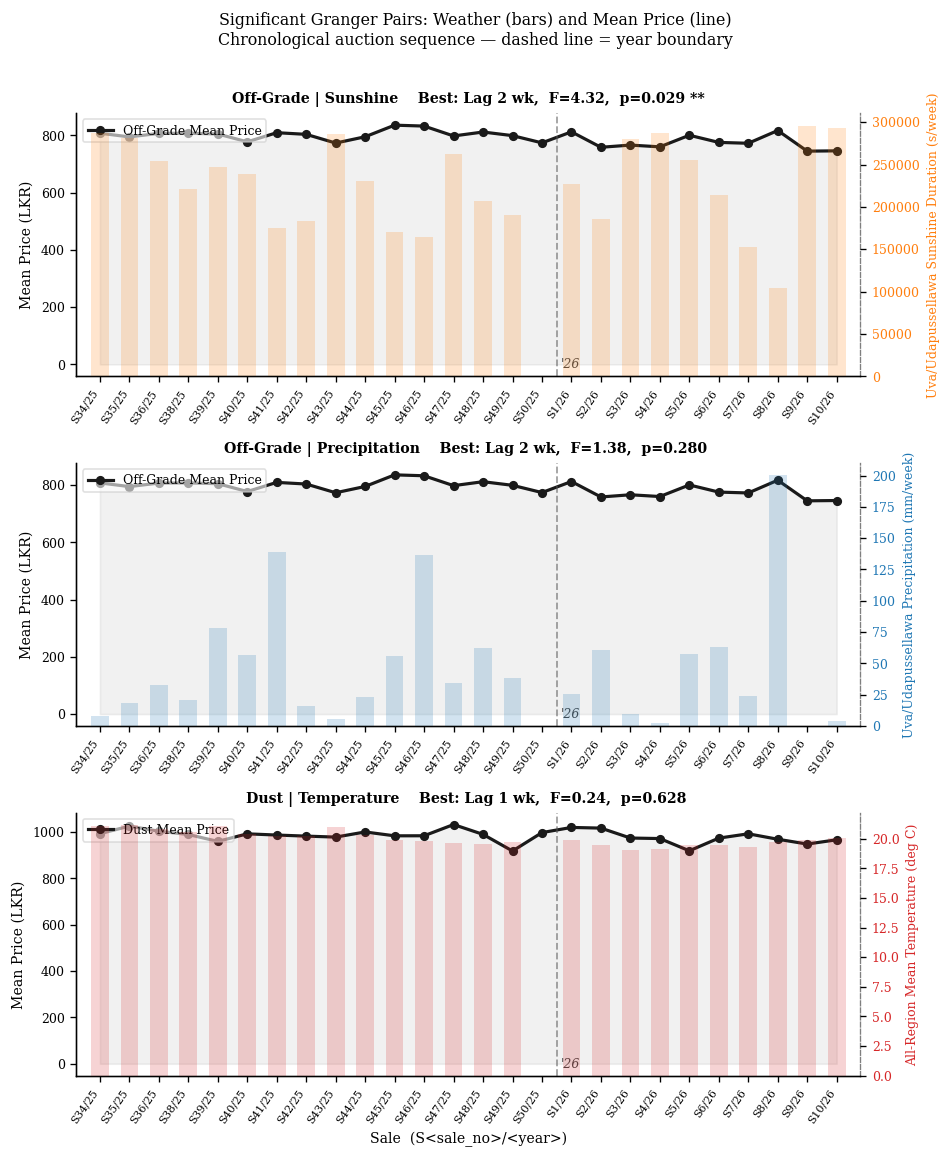

Fig C saved.


In [17]:
# Fig C -- Time-series overlays for significant Granger pairs
# X-axis: chronological sale sequence labelled S<sale_no>/<yr_short>
# Vertical dashed lines mark year boundaries.

SIG_PAIRS = [
    ('off_grade', 'Sunshine',      'Uva/Udapussellawa Sunshine Duration (s/week)', '#ff7f0e'),
    ('off_grade', 'Precipitation', 'Uva/Udapussellawa Precipitation (mm/week)',    '#1f77b4'),
    ('dust',      'Temperature',   'All-Region Mean Temperature (deg C)',           '#d62728'),
]

fig, axes = plt.subplots(3, 1, figsize=(8, 9.5))

for idx, (seg_key, var_name, weather_label, color) in enumerate(SIG_PAIRS):
    ax1 = axes[idx]
    ax2 = ax1.twinx()
    ax2.spines['right'].set_visible(True)

    ts        = segment_ts[seg_key].copy()
    wcol      = SEGMENT_WEATHER_MAP[seg_key][var_name]
    x_pos     = ts['chron_rank'].values
    labels    = ts['sale_label'].values
    price_s   = ts['price_mid_lkr'].values
    weather_s = ts[wcol].values
    years     = ts['sale_year_inf'].values

    # Weather bars (background)
    ax2.bar(x_pos, weather_s, color=color, alpha=0.20, width=0.6, zorder=1)
    ax2.set_ylabel(weather_label, color=color, fontsize=7.5)
    ax2.tick_params(axis='y', labelcolor=color, labelsize=7.5)
    ax2.spines['right'].set_linestyle('--')
    ax2.spines['right'].set_alpha(0.5)

    # Price line (foreground)
    ax1.plot(x_pos, price_s, color='#1a1a1a', linewidth=1.9,
             marker='o', markersize=4.5, zorder=3,
             label=f'{SEGMENT_DISPLAY[seg_key]} Mean Price')
    ax1.fill_between(x_pos, price_s, alpha=0.06, color='#1a1a1a', zorder=2)
    ax1.set_ylabel('Mean Price (LKR)', fontsize=8.5)
    ax1.tick_params(axis='y', labelsize=7.5)

    # Year boundary lines
    for k in range(1, len(years)):
        if years[k] != years[k - 1]:
            bx = (x_pos[k - 1] + x_pos[k]) / 2
            ax1.axvline(bx, color='#555555', linewidth=1.1,
                        linestyle='--', alpha=0.55, zorder=4)
            ax1.text(bx + 0.15, 0.02, f"'{str(int(years[k]))[-2:]}",
                     fontsize=7.5, color='#444444', va='bottom', style='italic',
                     transform=ax1.get_xaxis_transform())

    # X-axis labels: every label, rotated
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(labels, rotation=55, ha='right', fontsize=6.5)
    if idx == 2:
        ax1.set_xlabel('Sale  (S<sale_no>/<year>)', fontsize=8.5)

    ax1.set_xlim(x_pos[0] - 0.8, x_pos[-1] + 0.8)

    # Best-lag annotation in title
    pair_res = results_df[
        (results_df['seg_key'] == seg_key) &
        (results_df['weather_var'] == var_name)
    ].sort_values('p_value').iloc[0]
    best_lag, best_p, best_f, sig = (int(pair_res['lag']), pair_res['p_value'],
                                     pair_res['F_stat'], pair_res['sig'])

    ax1.set_title(
        f'{SEGMENT_DISPLAY[seg_key]} | {var_name}    '
        f'Best: Lag {best_lag} wk,  F={best_f:.2f},  p={best_p:.3f} {sig}',
        fontsize=8.5, fontweight='bold'
    )
    ax1.legend(loc='upper left', fontsize=7.5, framealpha=0.6)

fig.suptitle(
    'Significant Granger Pairs: Weather (bars) and Mean Price (line)\n'
    'Chronological auction sequence — dashed line = year boundary',
    fontsize=9.5, y=1.01
)
fig.tight_layout()
fig.savefig('../reports/figures/figC_granger_timeseries_overlays.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Fig C saved.')


### Fig D -- ADF Stationarity Summary

ADF p-values for every price and weather series tested. Red dashed line = p=0.05. Hatched bars were first-differenced before Granger testing.

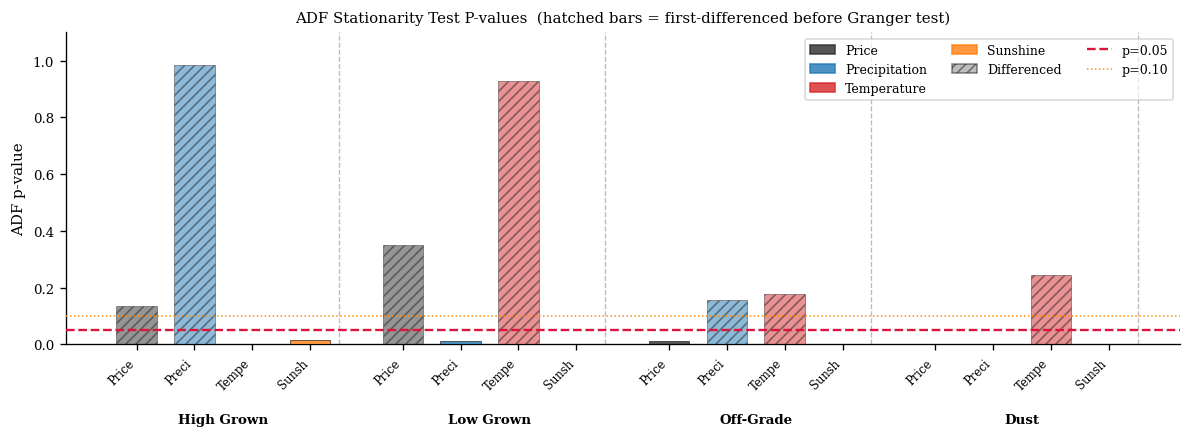

Fig D saved.


In [18]:
adf_records = []
for seg_key in SEGS_ORDER:
    ts = segment_ts[seg_key]
    stat_p, p_p = adf_result(ts['price_mid_lkr'])
    adf_records.append({'label': f'{SEGMENT_DISPLAY[seg_key]}\nPrice',
                        'segment': SEGMENT_DISPLAY[seg_key], 'series': 'Price',
                        'adf_p': p_p, 'diffed': not stat_p})
    for var_name in ['Precipitation', 'Temperature', 'Sunshine']:
        wcol = SEGMENT_WEATHER_MAP[seg_key][var_name]
        stat_w, p_w = adf_result(ts[wcol].dropna())
        adf_records.append({'label': f'{SEGMENT_DISPLAY[seg_key]}\n{var_name[:5]}',
                            'segment': SEGMENT_DISPLAY[seg_key], 'series': var_name,
                            'adf_p': p_w, 'diffed': not stat_w})

adf_df = pd.DataFrame(adf_records)

SERIES_COLORS = {'Price': '#2c2c2c', 'Precipitation': '#1f77b4',
                 'Temperature': '#d62728', 'Sunshine': '#ff7f0e'}

fig, ax = plt.subplots(figsize=(10, 3.8))

x        = 0
x_ticks  = []
x_labels = []
seg_info = []

for seg_key in SEGS_ORDER:
    seg_disp  = SEGMENT_DISPLAY[seg_key]
    seg_rows  = adf_df[adf_df['segment'] == seg_disp]
    seg_start = x

    for _, row in seg_rows.iterrows():
        color  = SERIES_COLORS[row['series']]
        height = float(row['adf_p']) if not pd.isna(row['adf_p']) else 1.0
        b = ax.bar(x, height, color=color, alpha=0.8 if not row['diffed'] else 0.5,
                   edgecolor='#222222', linewidth=0.5, width=0.7, zorder=3)
        if row['diffed']:
            b[0].set_hatch('////')
        x_ticks.append(x)
        x_labels.append(row['series'][:5])
        x += 1

    seg_info.append((seg_start, x - 1, seg_disp))
    ax.axvline(x - 0.5, color='#bbbbbb', linewidth=0.8, linestyle='--')
    x += 0.6

# Thresholds
ax.axhline(0.05, color='crimson', linewidth=1.4, linestyle='--', zorder=4, label='p=0.05')
ax.axhline(0.10, color='darkorange', linewidth=0.9, linestyle=':', zorder=4, label='p=0.10')

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=7, rotation=45, ha='right')
ax.set_ylabel('ADF p-value', fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_title('ADF Stationarity Test P-values  (hatched bars = first-differenced before Granger test)',
             fontsize=9)

# Segment labels below x-axis
for (s_start, s_end, name) in seg_info:
    mid = (s_start + s_end) / 2
    ax.text(mid, -0.22, name, ha='center', va='top', fontsize=8, fontweight='bold',
            transform=ax.get_xaxis_transform())

# Legend
legend_patches = []
for sname, sc in SERIES_COLORS.items():
    legend_patches.append(mpatches.Patch(color=sc, alpha=0.8, label=sname))
hatch_p = mpatches.Patch(facecolor='grey', hatch='////', edgecolor='#222', alpha=0.5, label='Differenced')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=legend_patches + [hatch_p] + handles,
          labels=list(SERIES_COLORS.keys()) + ['Differenced'] + labels,
          fontsize=7.5, loc='upper right', ncol=3, framealpha=0.7)

fig.tight_layout()
fig.savefig('../reports/figures/figD_granger_adf_stationarity.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Fig D saved.')


In [19]:
import os
print('Granger causality figures saved to reports/figures/:')
for fn in ['figA_granger_pvalue_heatmap.png',
           'figB_granger_fstat_profiles.png',
           'figC_granger_timeseries_overlays.png',
           'figD_granger_adf_stationarity.png']:
    path = f'../reports/figures/{fn}'
    size_kb = os.path.getsize(path) // 1024 if os.path.exists(path) else 0
    status = 'OK' if os.path.exists(path) else 'MISSING'
    print(f'  [{status}] {fn}  ({size_kb} KB)')


Granger causality figures saved to reports/figures/:
  [OK] figA_granger_pvalue_heatmap.png  (134 KB)
  [OK] figB_granger_fstat_profiles.png  (133 KB)
  [OK] figC_granger_timeseries_overlays.png  (261 KB)
  [OK] figD_granger_adf_stationarity.png  (86 KB)
